Citation stats? Log normal distribution

In [1]:
import pandas as pd
import ast

# load the CSV
#df = pd.read_csv("../data/SC_fulldata.csv")
df = pd.read_csv("../data/SC_related_data.csv")
# drop rows with 0 citations
df = df[df["times_cited"] > 0]

def safe_parse_concepts(cell):
    if isinstance(cell, str):
        try:
            return ast.literal_eval(cell)
        except:
            return []  # or np.nan
    return cell

def contains_superconduct(concepts):
    if isinstance(concepts, str):
        try:
            concepts = ast.literal_eval(concepts)
        except Exception as e:
            print(f"Bad string: {concepts[:50]}... → {e}")
            return False
    if not isinstance(concepts, list):
        # Then NAN...
        return False
    return any('superconduct' in d.get('concept', '').lower() for d in concepts if isinstance(d, dict))

from tqdm.notebook import tqdm
tqdm.pandas()
# Apply the filter across the column
#df = df[df['concepts_scores'].progress_apply(contains_superconduct)]

print(len(df))
# (optional) save cleaned version
#df.to_csv("../data/SC_related_data.csv", index=False)

df.head()

179538


,abstract,concepts_scores,doi,id,journal,times_cited,title,year
0,MEASUREMENTS have been made of the superconduc...,"[{'concept': 'magnetic moment', 'relevance': 0...",10.1038/1661071a0,pub.1013680774,"{'id': 'jour.1018957', 'title': 'Nature'}",15,Superconductivity of Tin Isotopes,1950
1,NaN,"[{'concept': 'empirical correlations', 'releva...",10.1103/physrev.80.911.2,pub.1060457159,"{'id': 'jour.1312024', 'title': 'Physical Revi...",16,An Empirical Correlation Among Superconductors,1950
2,Experiments have been carried out to measure t...,"[{'concept': 'normal metal', 'relevance': 0.70...",10.1103/physrev.80.894,pub.1060457137,"{'id': 'jour.1312024', 'title': 'Physical Revi...",8,Magnetic Moments and Eddy Currents in Spheres ...,1950
3,Measurements of heat flow in the superconducti...,"[{'concept': 'normal state', 'relevance': 0.69...",10.1103/physrev.80.859,pub.1060457128,"{'id': 'jour.1312024', 'title': 'Physical Revi...",48,Anomalous Heat Flow in Superconductors,1950
4,NaN,[{'concept': 'superconducting transition tempe...,10.1103/physrev.80.761,pub.1060457098,"{'id': 'jour.1312024', 'title': 'Physical Revi...",14,Mass Dependence of the Superconducting Transit...,1950


Create a new dataframe, do the citation filtering.

Max CPY: 1200.9333333333334


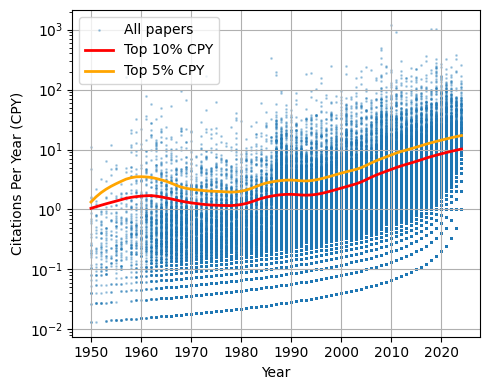

In [2]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Copy and compute CPY
df_cites = df.copy()[["doi", "id", "times_cited", "year"]]
df_cites['age'] = 2025 - df_cites['year']
df_cites['cpy'] = df_cites['times_cited'] / df_cites['age'].clip(lower=1)
print("Max CPY:", np.max(df_cites['cpy']))

# Compute both 90th and 95th percentile CPY per year
quantiles = df_cites.groupby('year')['cpy'].quantile([0.90, 0.95]).unstack().reset_index()
quantiles.columns = ['year', 'cpy_90', 'cpy_95']

# Smooth with LOWESS
lowess = sm.nonparametric.lowess
smooth_90 = lowess(quantiles['cpy_90'], quantiles['year'], frac=0.2)
smooth_95 = lowess(quantiles['cpy_95'], quantiles['year'], frac=0.2)

quantiles['cpy_90_smooth'] = smooth_90[:, 1]
quantiles['cpy_95_smooth'] = smooth_95[:, 1]

# Merge both thresholds back
df_cites = df_cites.merge(quantiles[['year', 'cpy_90_smooth', 'cpy_95_smooth']], on='year', how='left')

# Mark importance
df_cites['important_90'] = df_cites['cpy'] >= df_cites['cpy_90_smooth']
df_cites['important_95'] = df_cites['cpy'] >= df_cites['cpy_95_smooth']
df_cites_010 = df_cites[df_cites['important_90']]
df_cites_005 = df_cites[df_cites['important_95']]

# Plotting
plt.figure(figsize=(5, 4))
plt.scatter(df_cites['year'], df_cites['cpy'], s=1, alpha=0.3, label='All papers')
plt.plot(quantiles['year'], quantiles['cpy_90_smooth'], color='red', linewidth=2, label='Top 10% CPY')
plt.plot(quantiles['year'], quantiles['cpy_95_smooth'], color='orange', linewidth=2, label='Top 5% CPY')
plt.xlabel('Year')
plt.ylabel('Citations Per Year (CPY)')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
df_cites_010_full = df.merge(df_cites_010[['id']], on='id', how='inner')
df_cites_005_full = df.merge(df_cites_005[['id']], on='id', how='inner')
df_cites_010_full.to_csv("../data/SC_related_cites_010.csv", index=False)

print(len(df_cites_005), len(df_cites_010))
print(df_cites_005[df_cites_005['year'] == 2010]['cpy_90_smooth'].values[0])

df_2010 = df_cites_005[df_cites_005['year'] == 2010]
df_2010 = df_2010.sort_values(by='cpy', ascending=False).reset_index(drop=True)
df_2010.head(5)

9106 17937
4.669743568935962


,doi,id,times_cited,year,age,cpy,cpy_90_smooth,cpy_95_smooth,important_90,important_95
0,10.1103/revmodphys.82.3045,pub.1004083979,18014,2010,15,1200.933333,4.669744,8.122963,True,True
1,10.1103/physrevlett.105.077001,pub.1014648487,3175,2010,15,211.666667,4.669744,8.122963,True,True
2,10.1103/physrevlett.105.177002,pub.1028477691,2944,2010,15,196.266667,4.669744,8.122963,True,True
3,10.1088/1367-2630/12/6/065010,pub.1043782923,1933,2010,15,128.866667,4.669744,8.122963,True,True
4,10.1103/physrevlett.104.040502,pub.1039399458,1756,2010,15,117.066667,4.669744,8.122963,True,True


In [17]:
df_mini = df[df['doi'] == "10.1126/science.271.5249.618"]
print(df_mini['concepts_scores'].to_list())

["[{'concept': 'two-dimensional quantum magnets', 'relevance': 0.718}, {'concept': 'quasi-long-range order', 'relevance': 0.716}, {'concept': 'finite energy gap', 'relevance': 0.698}, {'concept': 'quantum magnets', 'relevance': 0.648}, {'concept': 'magnetic excitations', 'relevance': 0.642}, {'concept': 'ladder materials', 'relevance': 0.638}, {'concept': 'ground state', 'relevance': 0.638}, {'concept': 'magnetic order', 'relevance': 0.636}, {'concept': 'antiferromagnetically coupled S', 'relevance': 0.635}, {'concept': 'energy gap', 'relevance': 0.613}, {'concept': 'two-dimensional', 'relevance': 0.543}, {'concept': 'ladder', 'relevance': 0.523}, {'concept': 'assembly chain', 'relevance': 0.517}, {'concept': 'superconductivity', 'relevance': 0.503}, {'concept': 'spin', 'relevance': 0.497}, {'concept': 'magnetization', 'relevance': 0.473}, {'concept': 'excitation', 'relevance': 0.47}, {'concept': 'holes', 'relevance': 0.464}, {'concept': 'order', 'relevance': 0.459}, {'concept': 'trans